In [634]:
import pandas as pd


In [635]:
import os
print(os.getcwd())  # Check current working directory

c:\Users\shema\Documents\VScodeProject\Project2\Hackathon-2\jupyter_notebooks


In [636]:
df = pd.read_csv("Data/input/raw/BankChurners.csv")
df



,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


## Data clean and Transformation
I have started with a basic data clean below

In [637]:
# Drop duplicate rows if any
df = df.drop_duplicates()

# Check for missing values and display the count per column
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)

# For simplicity, drop rows with any missing values
df = df.dropna()

# Reset index after cleaning
df = df.reset_index(drop=True)

# Show the cleaned dataframe info
df.info()

Missing values per column:
 CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category     

In [638]:
df.columns = df.columns.str.lower().str.replace(" ", "_")  #Standardized column names
df

,clientnum,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1,naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


## Indepth Data Clean

In [639]:
# Remove outliers based on IQR for specified numeric columns with a less strict threshold
numeric_cols = ['customer_age', 'credit_limit', 'total_trans_amt', 'total_trans_ct', 'avg_utilization_ratio']

mask = pd.Series(True, index=df.index)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask &= (df[col] >= (Q1 - 3.0 * IQR)) & (df[col] <= (Q3 + 3.0 * IQR))

filtered_df = df[mask]
print(f"Rows before: {df.shape[0]}, after: {filtered_df.shape[0]}")



Rows before: 10127, after: 9390


In [640]:
print("Before filtering:", df.shape)

Before filtering: (10127, 23)


In [641]:
print("After filtering:", df.shape)


After filtering: (10127, 23)


In [642]:
print(df[numeric_cols].describe())  #Compare summary statistics

       customer_age  credit_limit  total_trans_amt  total_trans_ct  \
count  10127.000000  10127.000000     10127.000000    10127.000000   
mean      46.325960   8631.953698      4404.086304       64.858695   
std        8.016814   9088.776650      3397.129254       23.472570   
min       26.000000   1438.300000       510.000000       10.000000   
25%       41.000000   2555.000000      2155.500000       45.000000   
50%       46.000000   4549.000000      3899.000000       67.000000   
75%       52.000000  11067.500000      4741.000000       81.000000   
max       73.000000  34516.000000     18484.000000      139.000000   

       avg_utilization_ratio  
count           10127.000000  
mean                0.274894  
std                 0.275691  
min                 0.000000  
25%                 0.023000  
50%                 0.176000  
75%                 0.503000  
max                 0.999000  


In [643]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Extreme Values Check For Columns (Outliers)

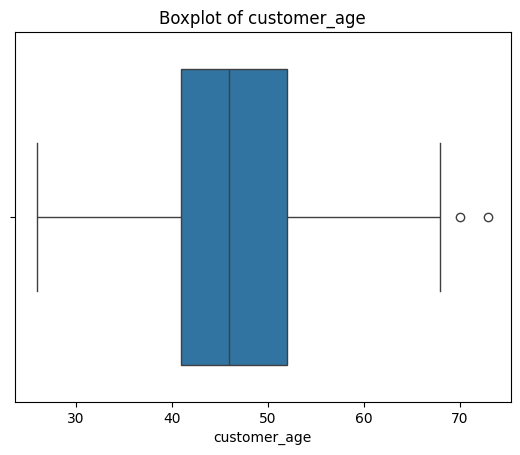

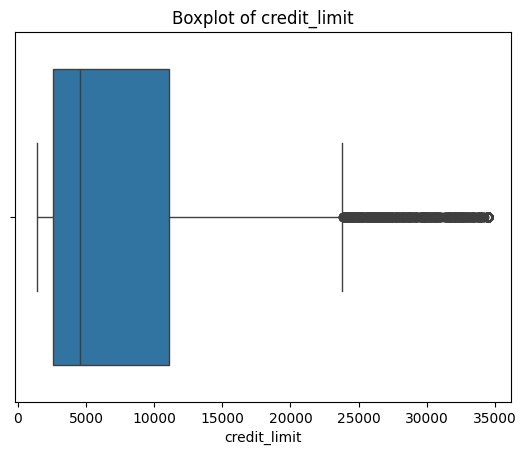

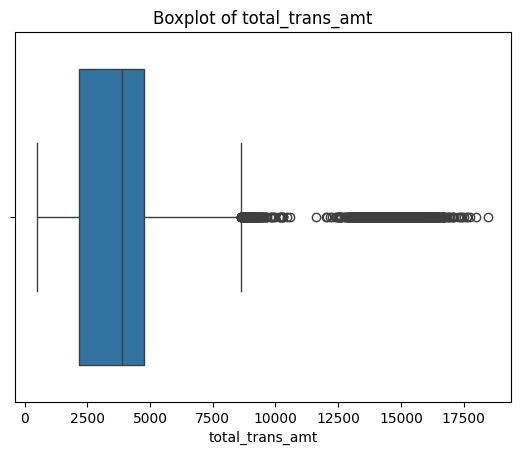

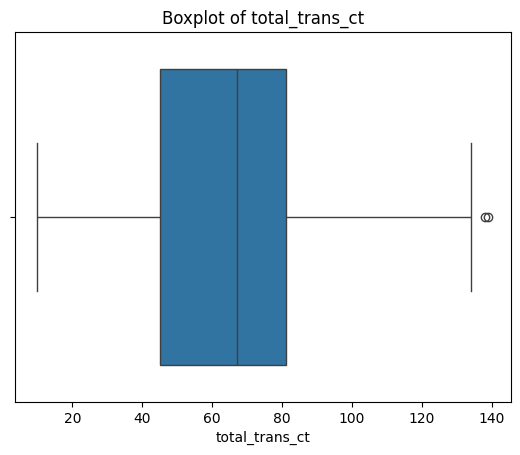

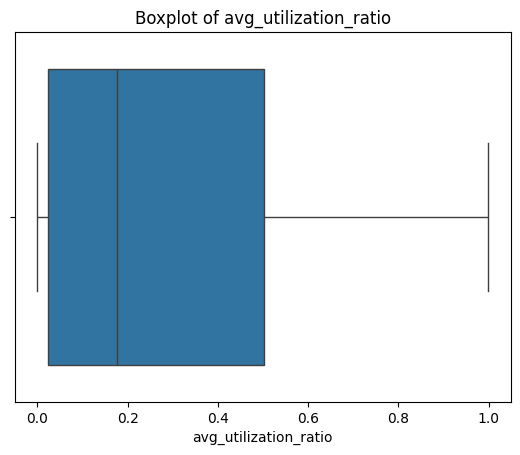

In [644]:
import seaborn as sns
# Visualizing the distribution of numeric columns using boxplots
import matplotlib.pyplot as plt

#checking for extreme values outside the whiskers

for col in numeric_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [645]:
import numpy as np


## Coding Below For Log Transformation
This will ensure there is no skewed data

In [646]:
df['log_credit_limit'] = np.log1p(df['credit_limit'])
print(df[['credit_limit', 'log_credit_limit']].head())


   credit_limit  log_credit_limit
0       12691.0          9.448727
1        8256.0          9.018817
2        3418.0          8.137103
3        3313.0          8.105911
4        4716.0          8.458928


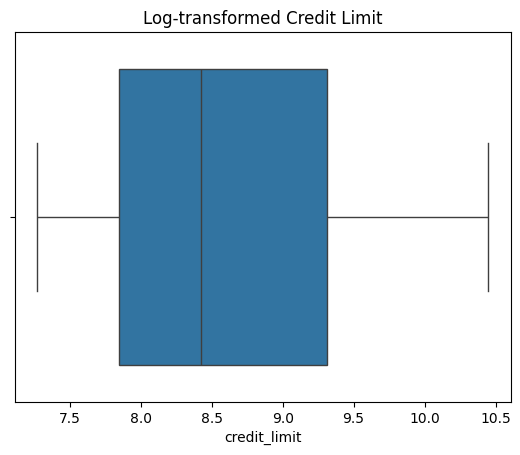

In [647]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualizing the log-transformed credit limit.

sns.boxplot(data=df, x=np.log1p(df['credit_limit']))
plt.title("Log-transformed Credit Limit")
plt.show()

As you can see above bosxplot the log-transformed credit limit distribution looks much more normalized compared to the original raw values.
The transformation has successfully compressed extreme outliers, making the spread more manageable while preserving overall trends.


In [648]:

#Applying log transformation to additional financial metrics can help smooth skewed distributions, especially for variables with extreme values. This can enhance model performance and interpretability. 


log_cols = ['total_trans_amt', 'avg_utilization_ratio', 'total_trans_ct']
for col in log_cols:
    df[f'log_{col}'] = np.log1p(df[col])

print(df[['total_trans_amt', 'log_total_trans_amt']].head())  # Sample check

   total_trans_amt  log_total_trans_amt
0             1144             7.043160
1             1291             7.163947
2             1887             7.543273
3             1171             7.066467
4              816             6.705639


Applying Log Transformation to Multiple Columns

In [649]:
import numpy as np

# List of columns to apply log transformation
log_columns = ['credit_limit', 'total_trans_amt', 'total_trans_ct', 'avg_utilization_ratio']

# Apply log transformation to each column
for col in log_columns:
    df[f'log_{col}'] = np.log1p(df[col])  # log1p prevents issues with zero values

# Check the transformed values
print(df[[f'log_{col}' for col in log_columns]].describe())

       log_credit_limit  log_total_trans_amt  log_total_trans_ct  \
count      10127.000000         10127.000000        10127.000000   
mean           8.603675             8.165164            4.114132   
std            0.933589             0.654246            0.402904   
min            7.271912             6.236370            2.397895   
25%            7.846199             7.676242            3.828641   
50%            8.422883             8.268732            4.219508   
75%            9.311859             8.464214            4.406719   
max           10.449207             9.824715            4.941642   

       log_avg_utilization_ratio  
count               10127.000000  
mean                    0.220917  
std                     0.206293  
min                     0.000000  
25%                     0.022739  
50%                     0.162119  
75%                     0.407463  
max                     0.692647  


visualizing the log-transformed data to confirm that the extreme values have been smoothed out


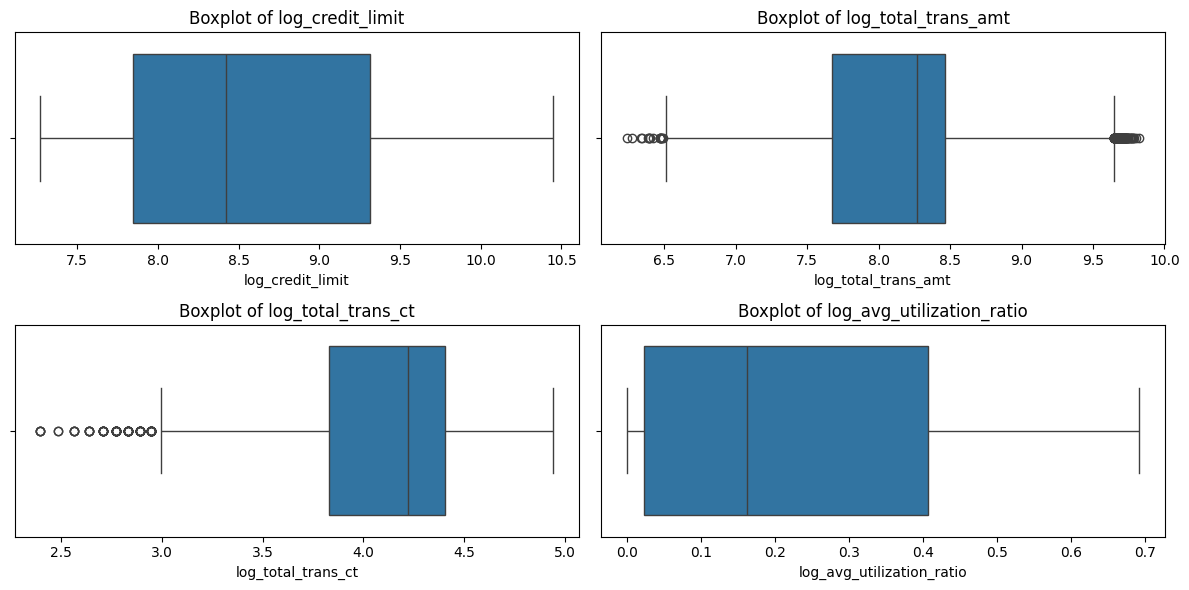

In [650]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of log-transformed columns
log_columns = ['log_credit_limit', 'log_total_trans_amt', 'log_total_trans_ct', 'log_avg_utilization_ratio']

# Create boxplots
plt.figure(figsize=(12, 6))
for i, col in enumerate(log_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

The transformation has compressed extreme values, making the distributions more balanced and improving interpretability.
- Log Credit Limit: Nicely centered with no extreme outliers, meaning high-credit customers are now better integrated into the dataset.
- Log Total Transaction Amount: Slight compression of lower values, but still maintaining the overall range.
- Log Total Transaction Count: Some minor outliers at the lower end, which is expected.
- Log Average Utilization Ratio: Looks well-balanced with a smooth distribution.



## Attrition Flag Column 

The below coding ensures that attrition flag column data is cleaned and is suitable for Power BI visualizations.


In [651]:
df['attrition_flag'] = df['attrition_flag'].map({'Existing Customer': 1, 'Attrited Customer': 0})


In [652]:
df[['attrition_flag']].head()  #Look at the transformed target variable

,attrition_flag
0,1
1,1
2,1
3,1
4,1


In [653]:
df['attrition_flag'].unique() #checking for unexpected values in the target variable

array([1, 0])

In [654]:
mode = df['attrition_flag'].mode()
if not mode.empty:
	df['attrition_flag'] = df['attrition_flag'].fillna(mode[0])
else:
	# If mode is empty (all NaN), fill with a default value, e.g., 1
	df['attrition_flag'] = df['attrition_flag'].fillna(1)

In [655]:
df[['attrition_flag']].head() #check the final target variable values

,attrition_flag
0,1
1,1
2,1
3,1
4,1


In [656]:
df['attrition_flag'].value_counts() #This will show how many customers are retained (1) versus attrited (0).


attrition_flag
1    8500
0    1627
Name: count, dtype: int64

In [657]:
df['attrition_flag'].unique()  # Checking for unexpected values in the target variable after filling NaNs

array([1, 0])

In [658]:
print(df.head())  # Display the first few rows of the cleaned DataFrame
print(df.info())  # Display DataFrame information
print(df[['attrition_flag']].value_counts())

   clientnum  attrition_flag  customer_age gender  dependent_count  \
0  768805383               1            45      M                3   
1  818770008               1            49      F                5   
2  713982108               1            51      M                3   
3  769911858               1            40      F                4   
4  709106358               1            40      M                3   

  education_level marital_status income_category card_category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   months_on_book  ...  total_trans_amt  total_trans_ct  total_ct_chng_q4_q1  \
0              39  ...             1144              42                1.625   
1              44  ...

In [660]:
df.to_csv('cleaned_credit_card_data.csv', index=False)
# Save the revised DataFrame to a new CSV file
df.to_csv('cleaned_credit_card_data_v2.csv', index=False)
